In [1]:
import ssl

# Completely disable the function that is scanning your broken Windows certificates
def break_windows_cert_store(*args, **kwargs):
    return None

ssl.SSLContext._load_windows_store_certs = break_windows_cert_store

In [2]:
from geometry_class import Geometry
import numpy as np
import pyvista as pv
pv.set_jupyter_backend('trame')
#%matplotlib widget

ERT Data generated with 452 measurements.
Mesh created: Mesh: Nodes: 125712 Cells: 764765 Boundaries: 1531985
Mesh contains data: Resistivity
Rhomap generated: [[1, 1.0], [2, 100.0], [3, 10.0], [4, 200.0]]
[[1, 1.0], [2, 100.0], [3, 10.0], [4, 200.0]]
Simulating ERT data...


19/06/26 - 16:06:29 - pyGIMLi - INFO - Calculate geometric factors.


Forward simulation complete. Simulated data saved to 'simulated_data.dat' with 452 measurements.


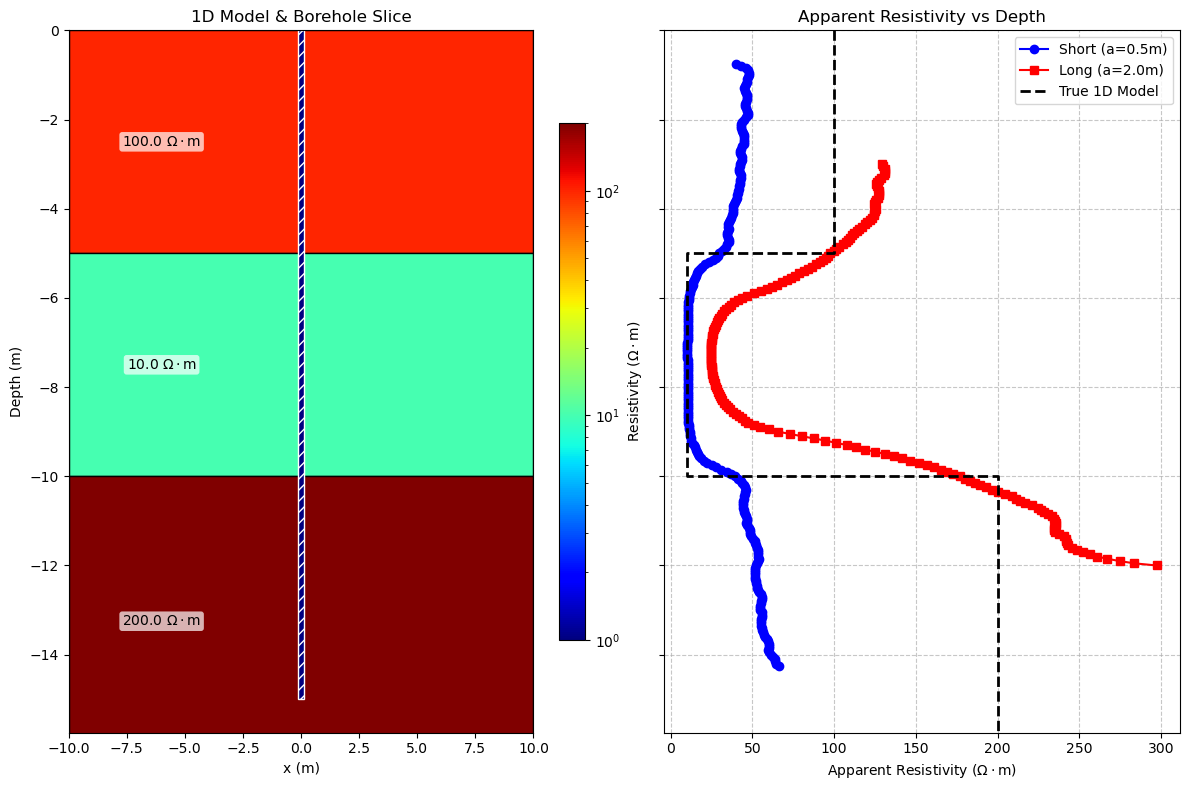

In [4]:
# Create a dummy layer configuration: [top, bottom, resistivity]
layers = np.array([
    [0.0, 5.0, 100.0],
    [5.0, 10.0, 10.0],
    [10.0, 15.0, 200.0]
])
geometry = Geometry(borehole_length=15.0, borehole_diameter=0.25, layer_1d_geometry=layers, background_resistivity=1.0)
geom = geometry.make_basic_geometry()

# Generate the electrode array and protocol prior to meshing
data = geometry.make_array(
    geom=geom, 
    abmn_order=(1, 4, 2, 3), 
    short_spacing=0.5, 
    long_spacing=2.0, 
    measuring_spacing=0.05
)
print(f"ERT Data generated with {data.size()} measurements.")

mesh = geometry.make_mesh(geom)
print(f"Mesh created: {mesh}")
print(f"Rhomap generated: {geometry.rhomap}")

# Run the forward simulation
simulated_data = geometry.run(mesh, data)
print(f"Forward simulation complete. Simulated data saved to 'simulated_data.dat' with {simulated_data.size()} measurements.")



# Visualize the boundary conditions (you can set show_internal=False to hide region boundaries)
#geometry.plot_boundary_conditions(mesh, show_internal=True)
# pg.show(mesh) # Uncomment to visualize using PyGIMLi

geometry.plot_model_and_data(simulated_data)